# Step 1: Member B (The Causal Analyst)
Objective: Look at the data over time and by distribution to identify nonlinear changes (the crash), asymmetric risk (fat-tailed distributions where a few nodes hold all the risk), and trace a specific causal cascade path versus a common exposure.

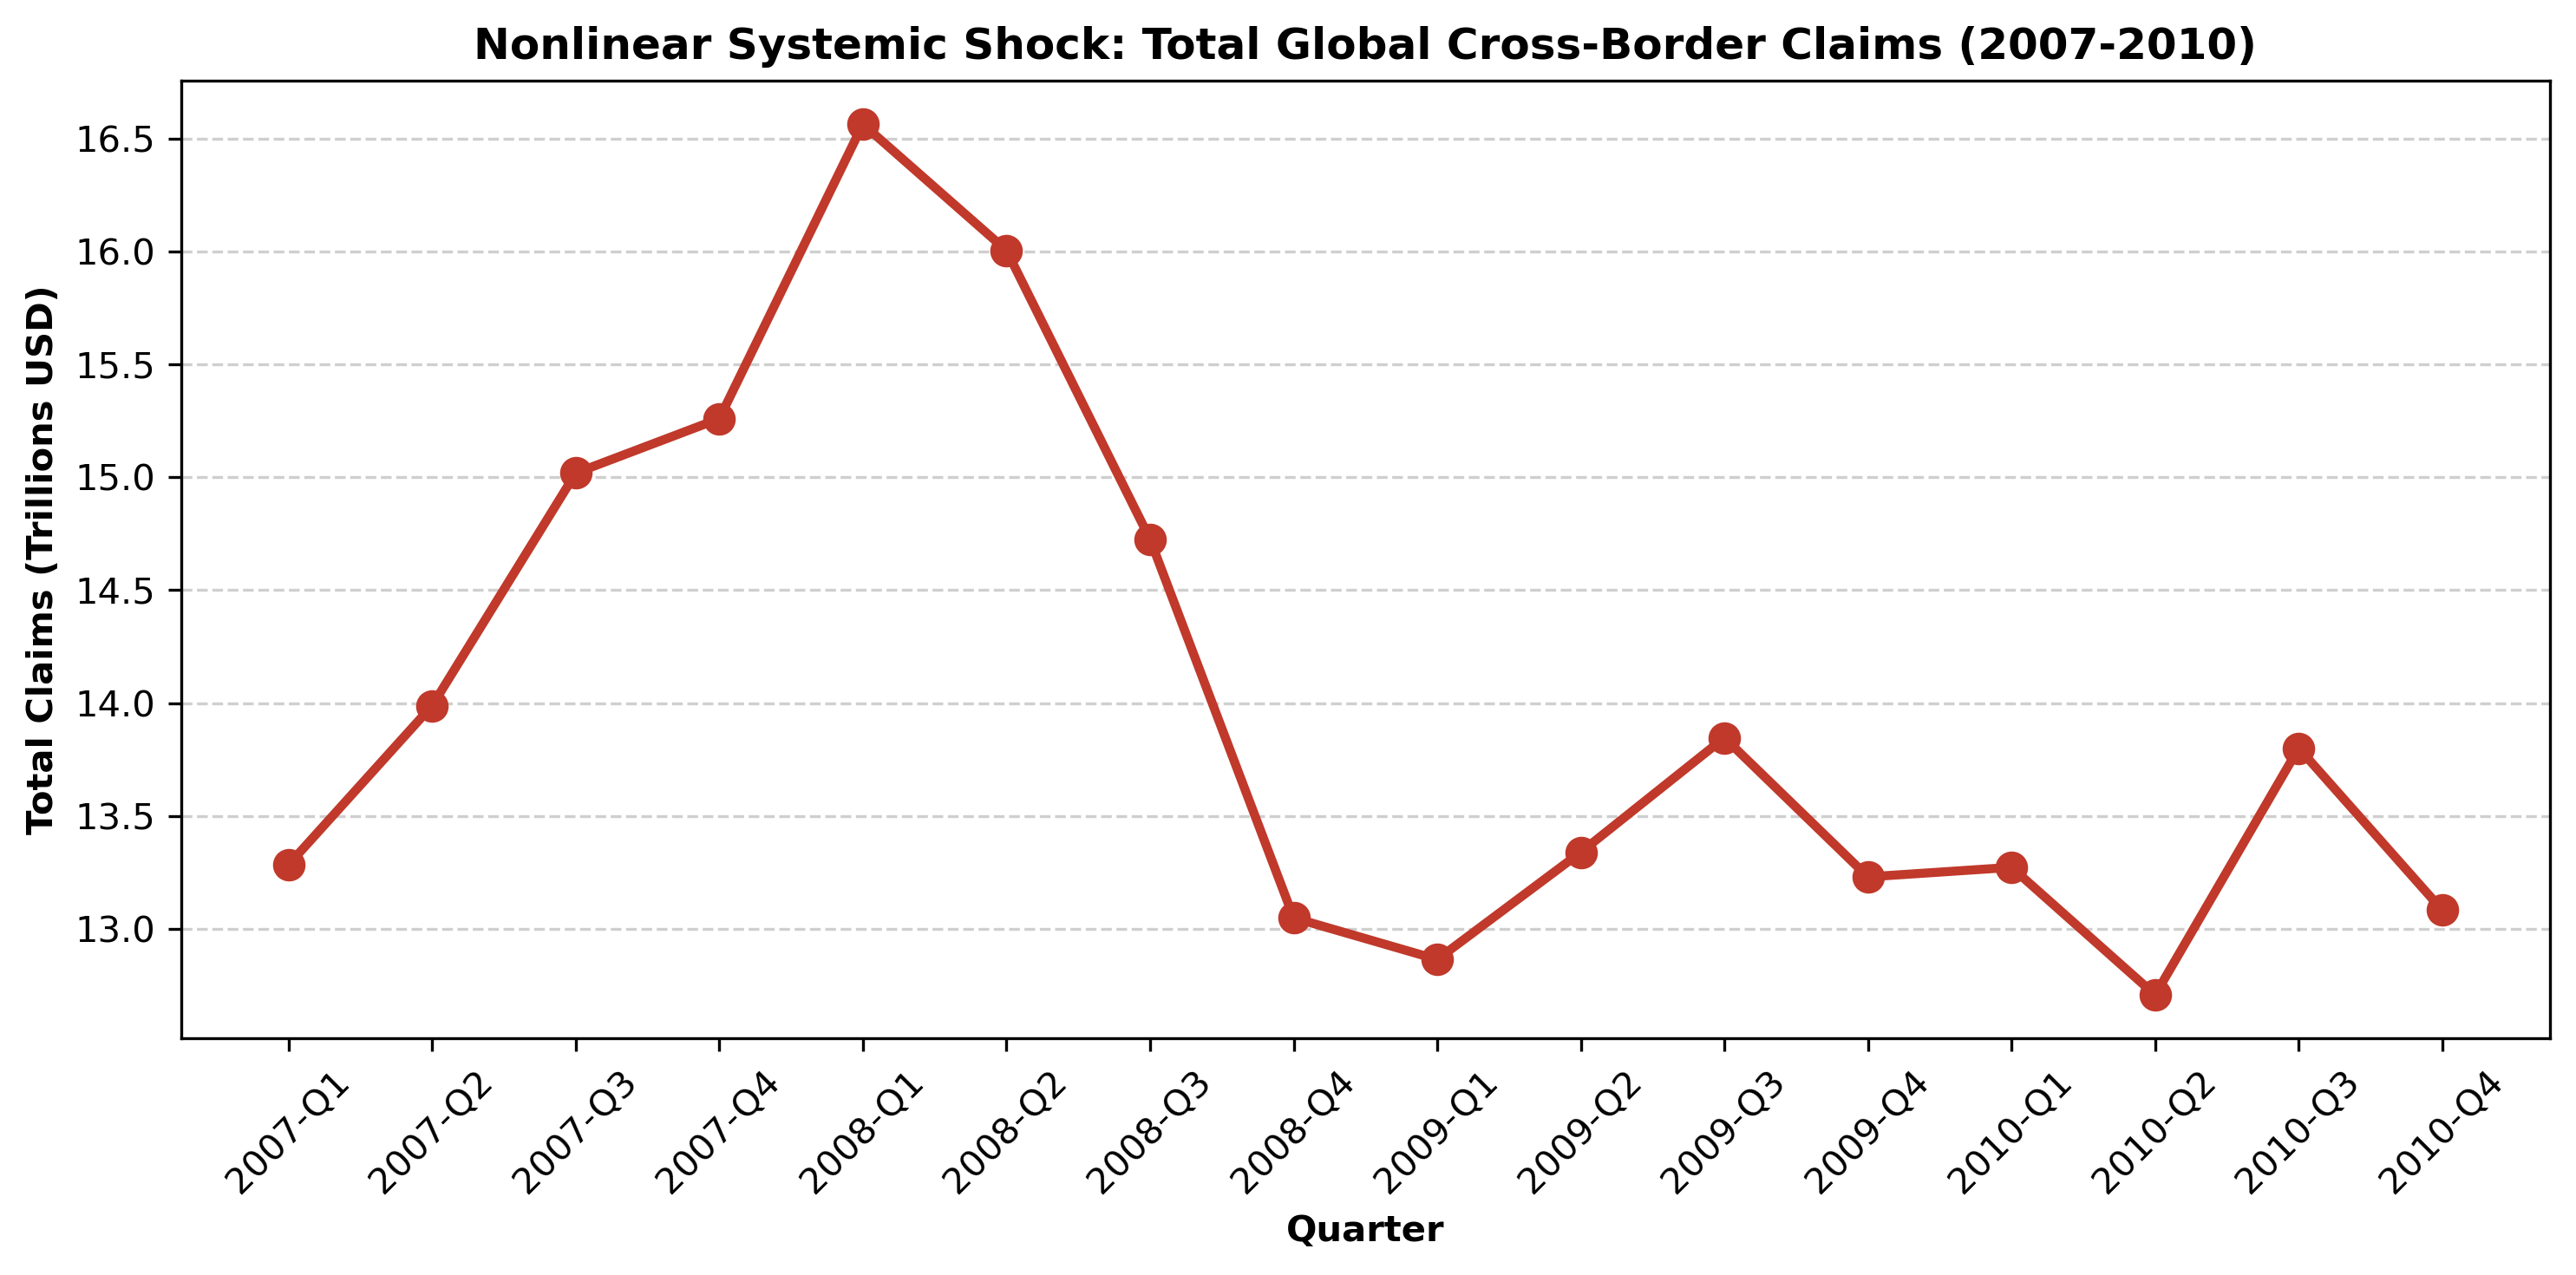

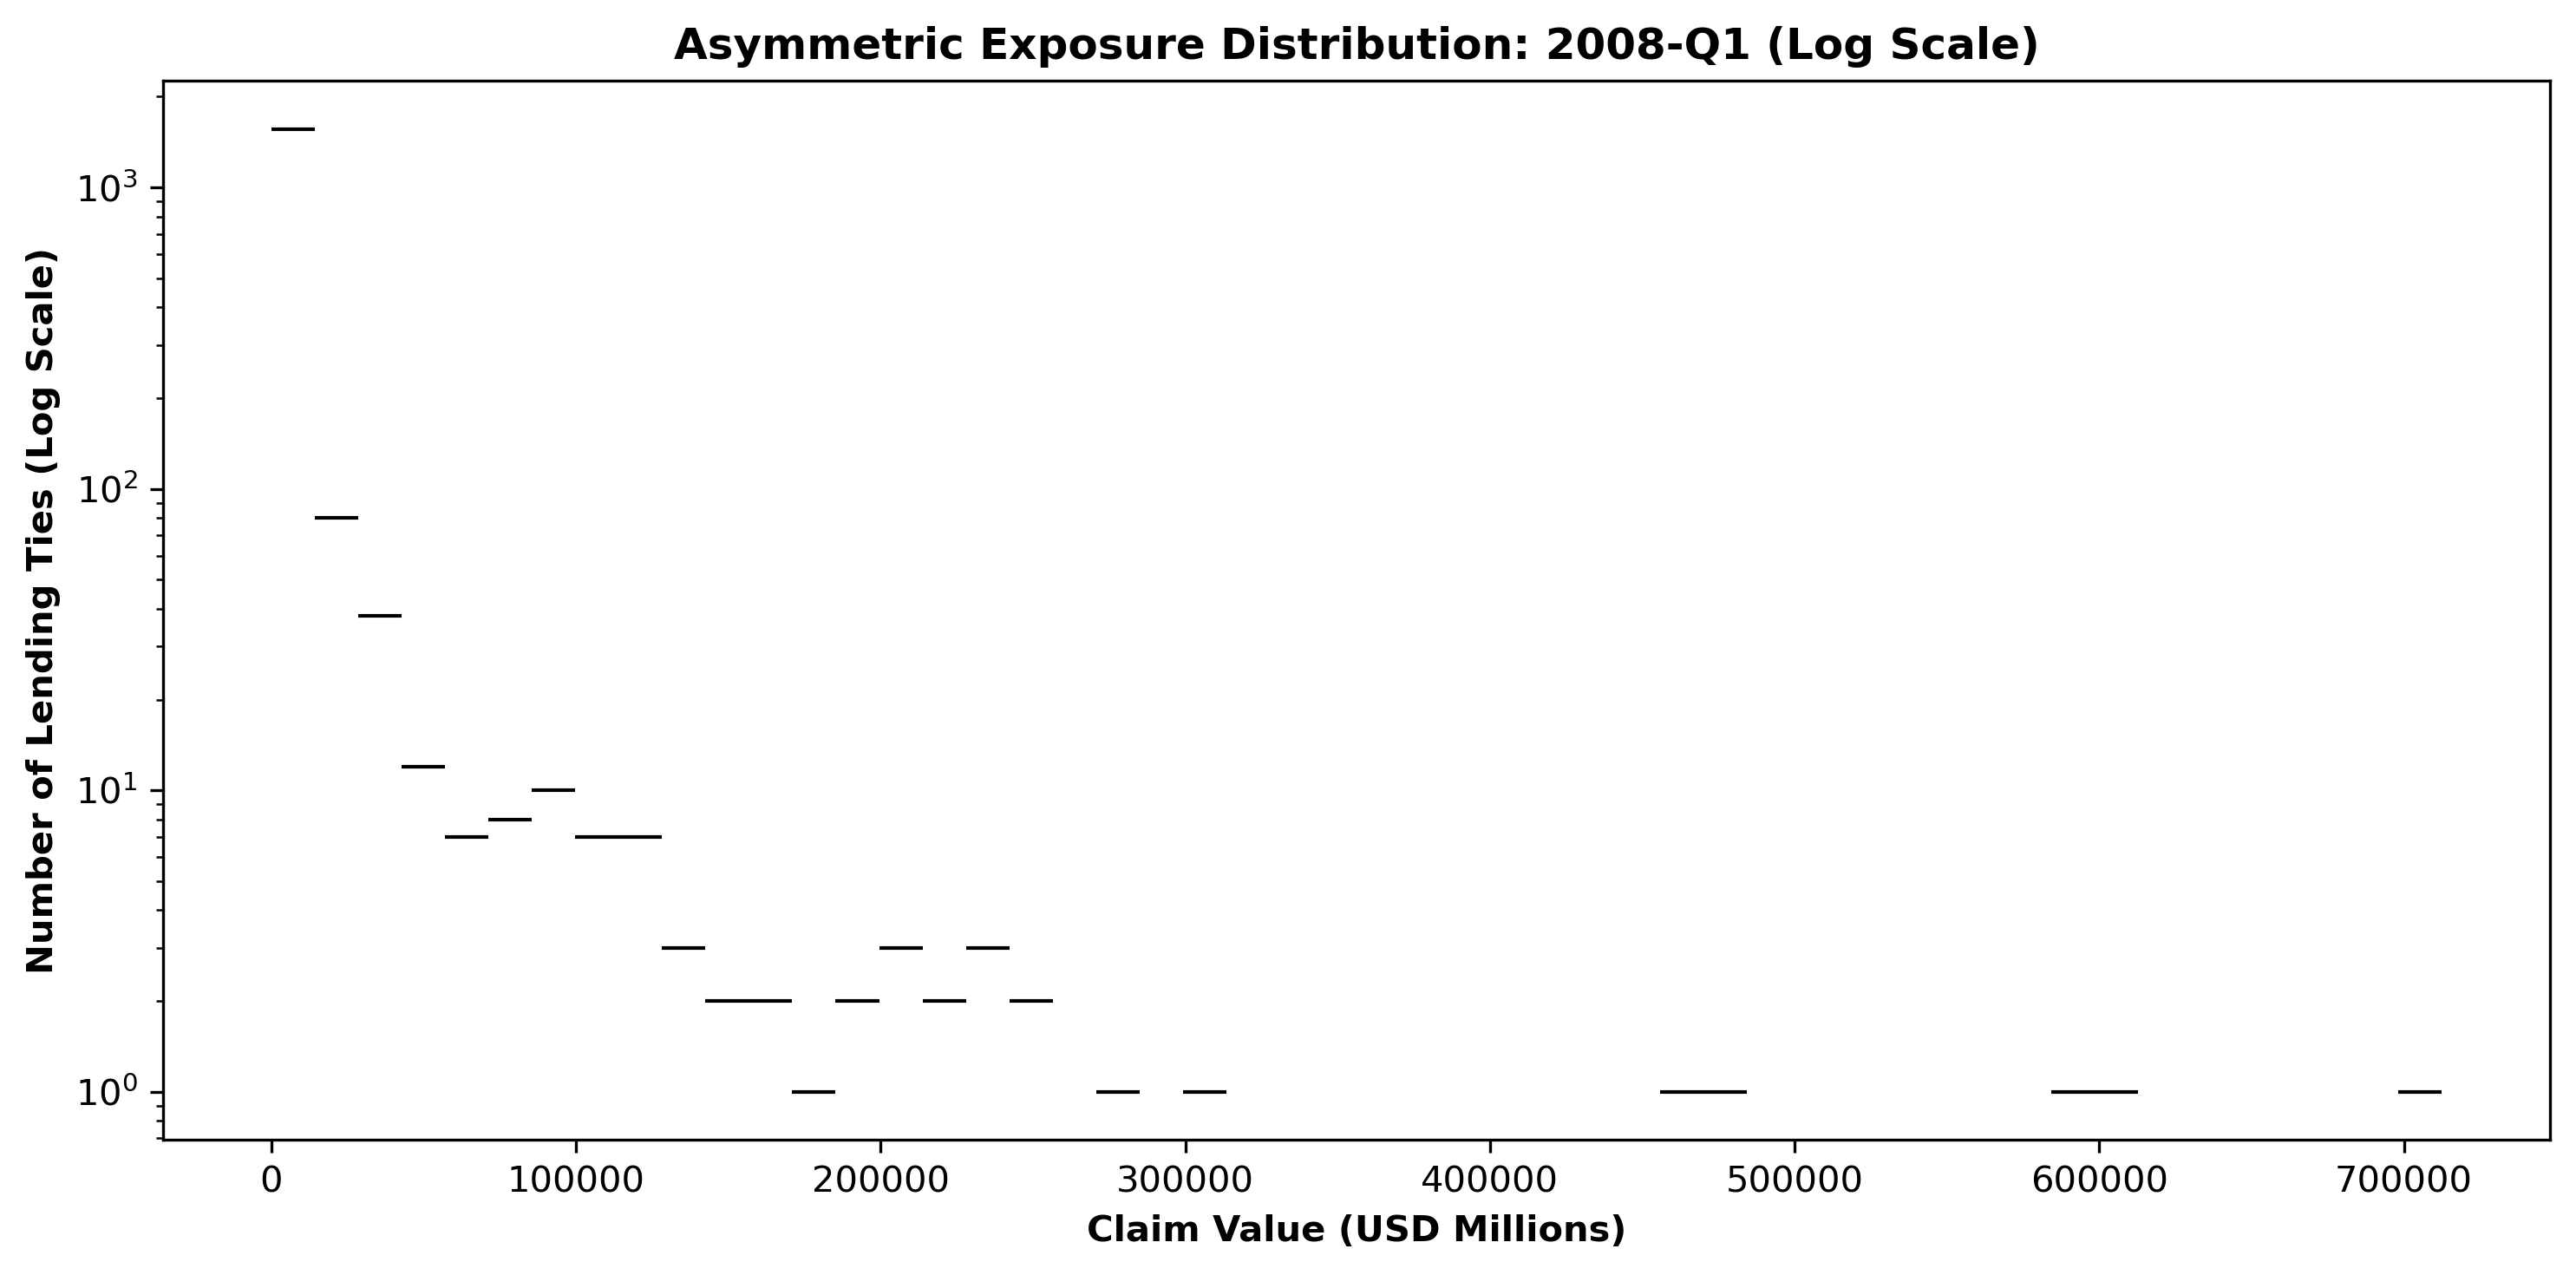

=== Asymmetric Risk Metrics (2008-Q1) ===
Total Global Exposure: $16,563,192 M
Exposure held by top 1% of edges: $5,684,307 M
Percentage of total risk concentrated in top 1% of connections: 34.32%

=== Finding Candidate Cascade Paths (A -> B -> C) ===
Candidate Cascade Path:
Germany ---($712,338M)---> United Kingdom ---($456,233M)---> United States

=== Finding Common Exposure (A -> C and B -> C) ===
Common Exposure to United States:
Japan ---($607,015M)---> United States
Germany ---($591,367M)---> United States


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")

# Load the positive edges dataset
df = pd.read_csv(PROCESSED_DIR / "bis_cbs_network_2007_2010_positive_edges.csv")

# -------------------------------------------------------------
# B1.1: Nonlinear Risk (The "Hockey-Stick" Time Series)
# -------------------------------------------------------------
# Calculate total global cross-border lending per quarter
timeline = df.groupby('period')['claim_value_usd_millions'].sum().reset_index()

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(timeline['period'], timeline['claim_value_usd_millions'] / 1e6, 
         marker='o', color='#c0392b', linewidth=2.5, markersize=8)
plt.title('Nonlinear Systemic Shock: Total Global Cross-Border Claims (2007-2010)', fontweight='bold')
plt.xlabel('Quarter', fontweight='bold')
plt.ylabel('Total Claims (Trillions USD)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_b1_nonlinear_shock_timeline.png")
plt.show()

# -------------------------------------------------------------
# B1.2: Asymmetric Risk (Fat-Tailed Distribution)
# -------------------------------------------------------------
# Look at the distribution of exposure sizes in 2008-Q1
df_2008q1 = df[df['period'] == '2008-Q1']

plt.figure(figsize=(10, 5), dpi=300)
sns.histplot(df_2008q1['claim_value_usd_millions'], bins=50, color='#2980b9', log_scale=(False, True))
plt.title('Asymmetric Exposure Distribution: 2008-Q1 (Log Scale)', fontweight='bold')
plt.xlabel('Claim Value (USD Millions)', fontweight='bold')
plt.ylabel('Number of Lending Ties (Log Scale)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_b2_fat_tail_distribution.png")
plt.show()

print("=== Asymmetric Risk Metrics (2008-Q1) ===")
total_exposure = df_2008q1['claim_value_usd_millions'].sum()
top_1_percent = df_2008q1.nlargest(int(len(df_2008q1)*0.01), 'claim_value_usd_millions')
top_1_sum = top_1_percent['claim_value_usd_millions'].sum()
print(f"Total Global Exposure: ${total_exposure:,.0f} M")
print(f"Exposure held by top 1% of edges: ${top_1_sum:,.0f} M")
print(f"Percentage of total risk concentrated in top 1% of connections: {(top_1_sum/total_exposure)*100:.2f}%\n")

# -------------------------------------------------------------
# B2: Causal Cascade vs. Common Exposure Search
# -------------------------------------------------------------
print("=== Finding Candidate Cascade Paths (A -> B -> C) ===")
# Find the largest bilateral exposure (A -> B)
top_edge = df_2008q1.nlargest(1, 'claim_value_usd_millions').iloc[0]
node_A = top_edge['Reporting country']
node_B = top_edge['Counterparty country']
val_AB = top_edge['claim_value_usd_millions']

# Find what B owes to someone else (B -> C)
b_edges = df_2008q1[df_2008q1['Reporting country'] == node_B]
if not b_edges.empty:
    next_edge = b_edges.nlargest(1, 'claim_value_usd_millions').iloc[0]
    node_C = next_edge['Counterparty country']
    val_BC = next_edge['claim_value_usd_millions']
    print(f"Candidate Cascade Path:")
    print(f"{node_A} ---(${val_AB:,.0f}M)---> {node_B} ---(${val_BC:,.0f}M)---> {node_C}\n")
else:
    print(f"Node {node_B} does not report outward claims in this filtered dataset.")

print("=== Finding Common Exposure (A -> C and B -> C) ===")
# Find a target C heavily borrowed from multiple sources
node_C_common = "United States" # Typical heavy borrower
common_edges = df_2008q1[df_2008q1['Counterparty country'] == node_C_common].nlargest(2, 'claim_value_usd_millions')
if len(common_edges) >= 2:
    lender1 = common_edges.iloc[0]['Reporting country']
    val1 = common_edges.iloc[0]['claim_value_usd_millions']
    lender2 = common_edges.iloc[1]['Reporting country']
    val2 = common_edges.iloc[1]['claim_value_usd_millions']
    print(f"Common Exposure to {node_C_common}:")
    print(f"{lender1} ---(${val1:,.0f}M)---> {node_C_common}")
    print(f"{lender2} ---(${val2:,.0f}M)---> {node_C_common}")

## Member B: The Causal Analyst
**Disruptive Force Focus:** Nonlinear Risk (Module 2) & Asymmetric Risk (Module 3)  
**Primary Analytical Lens:** Causal Inference  

---

### B1: Nonlinear and Asymmetric Risk Profiles

#### 1. Theoretical Definitions and Visual Signatures
*   **Nonlinear Risk:** A dynamic where a system's output is disproportionate to its input, meaning small incremental shocks can trigger sudden, massive phase transitions or collapses. Its visual signature is the **"hockey-stick" curve** (or an inverse hockey-stick/cliff-edge), where a trend appears stable or exponentially growing until it breaches a critical threshold and abruptly reverses.
*   **Asymmetric Risk:** A state where the probability distribution of outcomes or exposures is not normally distributed (bell-shaped) but heavily skewed. Its visual signature is a **fat-tailed or skewed distribution** (power-law), where the median exposure is negligible, but the tail contains extreme, catastrophic values that dominate the system's total risk profile. 

#### 2. Empirical Identification from the 2008-09 Dashboard
Using the constructed global cross-border banking network, we can empirically map these theoretical risks to the 2008 financial crisis (Bank for International Settlements [BIS], 2026).

*   **Nonlinear Threshold Candidate:** Tracking total global cross-border claims from 2007 to 2010 reveals a distinct nonlinear shock. Global lending peaked aggressively at a threshold of **$16.56 trillion** in 2008-Q1. Following this critical point, the system experienced a nonlinear phase transition, hemorrhaging over $3.5 trillion in connectivity to bottom out near $12.8 trillion by early 2009. 
*   **Fat-Tail Feature:** The cross-border banking network is heavily asymmetric. In 2008-Q1, the total global exposure was $16,563,192 million. However, the exposure distribution is heavily right-skewed: the **top 1% of lending connections held $5,684,307 million**. This means that just 1% of the network's edges concentrated **34.32%** of the entire global systemic risk.

![fig b1](../figures/fig_b1_nonlinear_shock_timeline.png)

![fig b2](../figures/fig_b2_fat_tail_distribution.png)

---

### B2: Causal Pathways, Confounders, and the "But For" Test

#### 1. Distinguishing Cascades from Common Exposures
To understand how systemic failure propagated, we must untangle genuine causal contagion from correlated external shocks. 

*   **Candidate Cascade Path ($A \rightarrow B \rightarrow C$):** A genuine cascade implies sequential contagion. Our data identifies a massive sequential path: **Germany** extended $712,338 million to the **United Kingdom**, which in turn extended $456,233 million to the **United States**. If this is a pure cascade, a default in the US (C) causes a liquidity shortfall in the UK (B), which subsequently forces a default onto Germany (A).
*   **Common Exposure ($A \rightarrow C$ and $B \rightarrow C$):** A common exposure implies that multiple nodes are independently vulnerable to the same external shock. The data reveals that the United States is a massive common denominator. **Japan** holds $607,015 million in direct claims on the US, and **Germany** simultaneously holds $591,367 million in direct claims on the US. 

#### 2. Applying the "But For" Legal Test
To test the causal weight of the $A \rightarrow B \rightarrow C$ cascade, we apply the "but for" counterfactual: *But for the United Kingdom's transmission of the shock, would Germany have suffered systemic impairment?*

The data suggests Yes — Germany's collapse was causally overdetermined. Even if we sever the Germany → UK edge (the cascade transmission mechanism), Germany would still suffer catastrophic impairment because it possesses a $591,367 million direct common exposure to the United States. Therefore, the network suffers from a deadly interaction of both forces: the cascade path exacerbated the crisis, but common exposure alone was sufficient to trigger systemic failure independently.

#### 3. Data Confounders and Biases
When inferring causality from this network data, we must account for statistical limitations:
*   **Confounder:** Underlying asset quality (e.g., exposure to unmapped subprime Mortgage-Backed Securities). The BIS Table B4 data tracks aggregate counterparty claims but not the underlying instrument quality. A drop in cross-border lending between two countries may be confounded by an unobserved global repricing of toxic collateral, rather than pure bilateral contagion.
*   **Survivorship Bias Risk:** The dataset records reported claims at the end of each quarter. If a major banking institution structurally fails and ceases reporting during the crisis window (e.g., Lehman Brothers), its edges disappear from subsequent periods. This selection bias makes the post-2008 network appear artificially "cleaner" or less risky, as the most fatal links are erased from the survival sample rather than recorded as defaults.

---

### References
*   Bank for International Settlements. (2026). *Consolidated banking statistics: Detailed view of positions on individual countries (Table B4)* [Data set]. BIS Data Portal. https://data.bis.org/topics/CBS/data